In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
df = pd.read_csv('../data/processed/X_sample.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200000, 28)


,lepton_pT,lepton_eta,lepton_phi,missing_E_mag,missing_E_phi,jet1_pT,jet1_eta,jet1_phi,jet1_btag,jet2_pT,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,0.548478,-0.058492,0.979747,0.886419,0.773973,1.551918,0.937722,0.576157,2.173076,1.391360,...,2.452204,-1.606737,0.000000,1.319653,0.891900,0.980309,0.739218,3.544772,2.096405,1.791715
1,0.577577,-0.320490,0.009849,0.824704,-1.251037,0.706566,-1.638856,-0.636922,0.000000,1.251607,...,-1.203890,1.031420,3.101961,0.868531,1.138811,0.992165,0.831389,0.891734,0.958478,0.819518
2,5.065509,-1.502888,-0.564538,1.623411,-0.701304,1.297067,-2.412226,0.922641,0.000000,2.297109,...,-1.362127,-1.156149,0.000000,0.754152,1.115983,1.011100,0.816364,0.339321,0.773463,1.278743
3,0.851907,-0.946752,0.742821,1.373478,1.176896,0.705192,0.044535,-0.453421,2.173076,0.585955,...,-1.152255,-1.049051,0.000000,0.295120,0.711861,0.987153,0.815544,0.921860,1.006651,0.846980
4,0.520844,0.889179,-1.101643,0.585859,-0.184083,1.157915,0.453500,0.072784,0.000000,0.910912,...,1.025577,-1.585096,3.101961,1.677824,1.429353,0.983400,0.903238,0.378181,1.160369,1.324489


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [6]:
# Store results for comparison
pca_results = {}

for n_components in [2, 5, 10]:
    start_time = time.time()

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    elapsed = time.time() - start_time

    pca_results[n_components] = {
        'transformed_data': X_pca,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca.explained_variance_ratio_),
        'runtime': elapsed
    }

    print(f"PCA with {n_components} components:")
    print(f"    Runtime: {elapsed:.2f} seconds")
    print(f"    Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")
    print()

PCA with 2 components:
    Runtime: 0.04 seconds
    Total variance explained: 21.53%

PCA with 5 components:
    Runtime: 0.04 seconds
    Total variance explained: 37.78%

PCA with 10 components:
    Runtime: 0.04 seconds
    Total variance explained: 59.64%



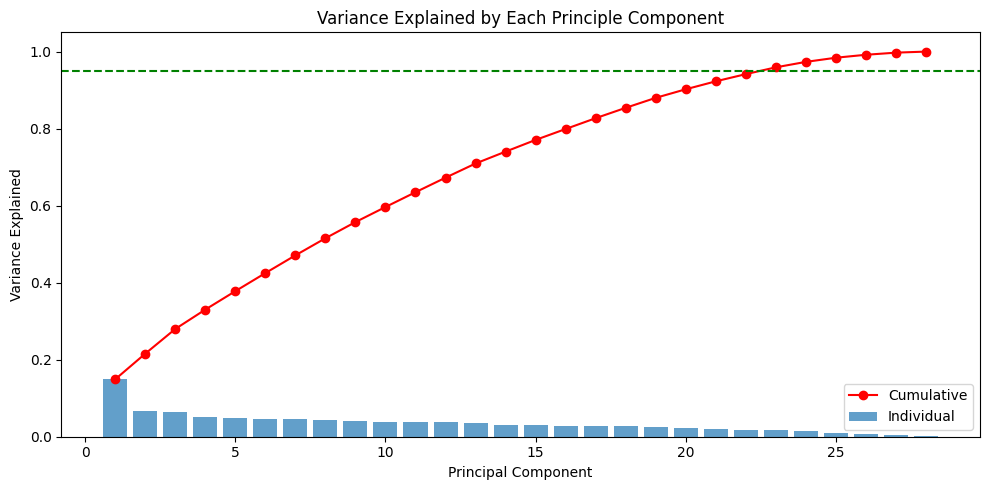

In [7]:
pca_full = PCA(n_components = 28)
pca_full.fit(X_scaled)

plt.figure(figsize = (10,5))
plt.bar(range(1, 29), pca_full.explained_variance_ratio_, alpha = 0.7, label = "Individual")
plt.plot(range(1,29), np.cumsum(pca_full.explained_variance_ratio_), "r-o", label = "Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Variance Explained by Each Principle Component")
plt.legend()
plt.axhline(y = 0.95, color = "g", linestyle = "--", label = "95% threshold")
plt.tight_layout()
plt.savefig("variance_explained.png")
plt.show()

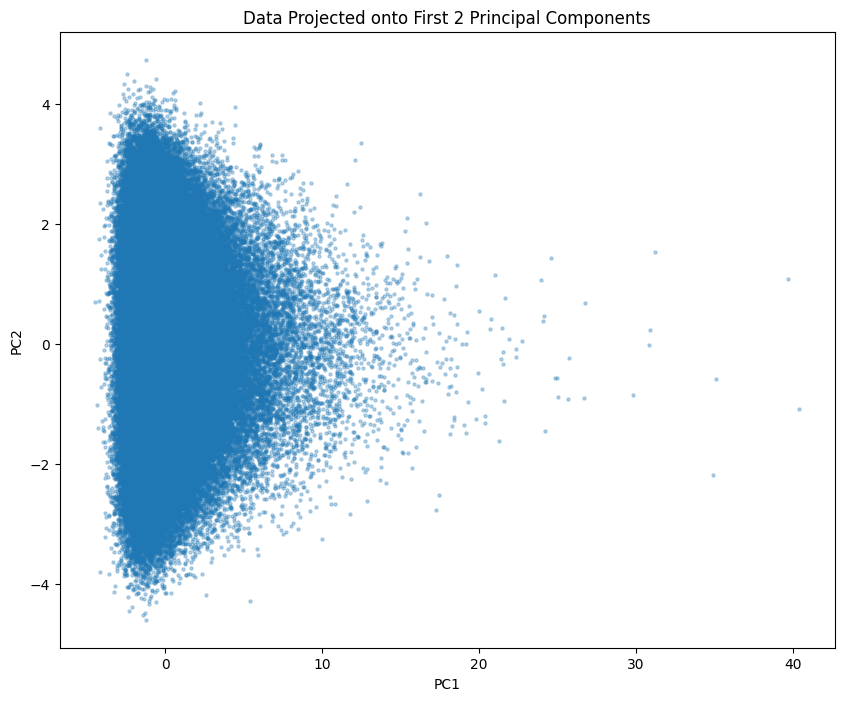

In [8]:
X_2d = pca_results[2]["transformed_data"]

plt.figure(figsize = (10,8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha = 0.3, s = 5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data Projected onto First 2 Principal Components")
plt.savefig("pca_2d_scatter.png")
plt.show()

In [10]:
pd.DataFrame(pca_results[2]['transformed_data']).to_csv('../data/processed/X_pca_2.csv', index=False)
pd.DataFrame(pca_results[5]['transformed_data']).to_csv('../data/processed/X_pca_5.csv', index=False)
pd.DataFrame(pca_results[10]['transformed_data']).to_csv('../data/processed/X_pca_10.csv', index=False)

print("Saved to data/processed/:")
print("  - X_pca_2.csv")
print("  - X_pca_5.csv")
print("  - X_pca_10.csv")

Saved to data/processed/:
  - X_pca_2.csv
  - X_pca_5.csv
  - X_pca_10.csv


In [11]:
summary = pd.DataFrame({
    "Components": [2,5,10],
    "Variance Explained (%)": [
        sum(pca_results[2]["explained_variance_ratio"])*100,
        sum(pca_results[5]["explained_variance_ratio"])*100,
        sum(pca_results[10]["explained_variance_ratio"])*100
    ],
    "Runtime (sec)": [
        pca_results[2]["runtime"],
        pca_results[5]["runtime"],
        pca_results[10]["runtime"]
    ]
})
print(summary.to_string(index=False))

 Components  Variance Explained (%)  Runtime (sec)
          2               21.529785       0.036319
          5               37.779478       0.037961
         10               59.640551       0.040365
